# Week 6 - Day 5: Tuning, Evaluation, Sprint Review

This notebook closes Sprint 1 for the **Heart Disease Classification** project.

I continue directly from the Week 6 work:

- same `heart.csv` dataset and cleaning rules;
- same Day 1 train/test split for a fair baseline comparison;
- same feature engineering and preprocessing logic;
- Day 4 neural-network result kept as the reference NN;
- Day 5 model selection uses **training + validation only**;
- the Day 1 test split is used only after the Day 5 configuration is locked.

The test split was already evaluated in Day 4 as part of the internship workflow, so I do **not** claim that it is completely unseen across the whole week. The important control here is that **no Day 5 tuning decision uses test metrics**.


## 1. Day 5 Backlog - Completed

| Task | Status |
|---|---|
| Add deterministic seeding | completed |
| Add `EarlyStopping` and `ModelCheckpoint` | completed |
| Tune learning rate | completed |
| Tune width/depth | completed |
| Tune dropout | completed |
| Tune batch size | completed |
| Track experiments and validation metrics | completed |
| Select the best configuration from validation only | completed |
| Evaluate the locked model on the Day 1 test split | completed |
| Compare Day 1 baseline vs Day 4 NN vs Day 5 tuned NN | completed |
| Prepare Sprint Review and Retrospective | completed |

The goal is not to force the neural network to win. The goal is to make the tuning process reproducible, explainable, and comparable to the established baseline.


## 2. Imports and Reproducibility

I set seeds for Python, NumPy, and TensorFlow. Deep-learning runs can still vary slightly across machines, but this keeps the notebook as reproducible as practical for this sprint.


In [1]:
from pathlib import Path
import os
import random
import warnings

os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

cwd = Path.cwd().resolve()

data_candidates = [cwd / "heart.csv", cwd / "data" / "heart.csv"]
for root in [cwd, *cwd.parents]:
    data_candidates.append(
        root / "final-project" / "heart-disease-classification" / "data" / "heart.csv"
    )

DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "heart.csv was not found. Keep the repository structure or place heart.csv "
        "beside this notebook / under a local data directory."
    )

OUTPUT_DIR = cwd / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "day5_checkpoints"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Dataset file:", DATA_PATH.name)
print("Output folder:", OUTPUT_DIR.name)


TensorFlow: 2.21.0
Dataset file: heart.csv
Output folder: outputs


## 3. Load and Clean the Same Data

The raw dataset is not edited. I only replace medically invalid zeros in memory, exactly as in Day 1 and Day 4:

- `RestingBP = 0` is invalid;
- `Cholesterol = 0` is treated as missing/unknown.


In [2]:
df = pd.read_csv(DATA_PATH)

df_clean = df.copy()
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

data_audit = pd.DataFrame(
    {
        "rows": [df_clean.shape[0]],
        "input_features": [df_clean.shape[1] - 1],
        "target": ["HeartDisease"],
        "target_positive_rate": [df_clean["HeartDisease"].mean()],
        "restingbp_missing_after_cleaning": [df_clean["RestingBP"].isna().sum()],
        "cholesterol_missing_after_cleaning": [df_clean["Cholesterol"].isna().sum()],
    }
)

display(data_audit.round(4))


,rows,input_features,target,target_positive_rate,restingbp_missing_after_cleaning,cholesterol_missing_after_cleaning
0,918,11,HeartDisease,0.5534,1,172


## 4. Frozen Split and Validation Split

I recreate the same Day 1 held-out test split so the final comparison stays apples-to-apples, then split the training portion into train and validation.

**Day 5 tuning and model selection use only the training and validation splits.**  
The test split was already inspected in Day 4 per the weekly workflow, but it is not consulted again until the Day 5 configuration is locked.


In [3]:
X = df_clean.drop(columns="HeartDisease")
y = df_clean["HeartDisease"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

split_summary = pd.DataFrame(
    {
        "samples": [len(X_train), len(X_val), len(X_test)],
        "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)

display(split_summary.round(4))


,samples,positive_rate
train,587,0.5537
validation,147,0.5510
test,184,0.5543


## 5. Same Feature Engineering and Preprocessing

The transformer is fit only on the training split. Validation and test are transformed with the fitted transformer.


In [4]:
def add_engineered_features(X_input):
    X_new = X_input.copy()

    expected_max_hr = 220 - X_new["Age"]
    X_new["MaxHRRatio"] = X_new["MaxHR"] / expected_max_hr.replace(0, np.nan)
    X_new["OldpeakPositive"] = (X_new["Oldpeak"] > 0).astype(int)
    X_new["ExerciseOldpeak"] = (
        X_new["Oldpeak"] * (X_new["ExerciseAngina"] == "Y").astype(int)
    )
    X_new["AgeGroup"] = pd.cut(
        X_new["Age"],
        bins=[0, 45, 55, 65, 120],
        labels=["under_45", "45_55", "56_65", "over_65"],
        include_lowest=True,
    ).astype("object")

    return X_new


numeric_features = [
    "Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR",
    "Oldpeak", "MaxHRRatio", "OldpeakPositive", "ExerciseOldpeak",
]

categorical_features = [
    "Sex", "ChestPainType", "RestingECG",
    "ExerciseAngina", "ST_Slope", "AgeGroup",
]

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    [
        ("num", numeric_preprocessor, numeric_features),
        ("cat", categorical_preprocessor, categorical_features),
    ],
    sparse_threshold=0.0,
)

X_train_nn = preprocessor.fit_transform(add_engineered_features(X_train)).astype(np.float32)
X_val_nn = preprocessor.transform(add_engineered_features(X_val)).astype(np.float32)
X_test_nn = preprocessor.transform(add_engineered_features(X_test)).astype(np.float32)

y_train_nn = y_train.to_numpy(dtype=np.float32)
y_val_nn = y_val.to_numpy(dtype=np.float32)
y_test_nn = y_test.to_numpy(dtype=np.float32)

print("Train shape:", X_train_nn.shape)
print("Validation shape:", X_val_nn.shape)
print("Test shape:", X_test_nn.shape)
print("Input features after preprocessing:", X_train_nn.shape[1])


Train shape: (587, 27)
Validation shape: (147, 27)
Test shape: (184, 27)
Input features after preprocessing: 27


## 6. Training Helpers

Day 4 used:

`Dense(64, ReLU) -> BatchNormalization -> Dropout(0.3) -> Dense(32, ReLU) -> Dense(1, Sigmoid)`

For Day 5 I keep the same starting width/depth and BatchNorm placement, then use one reusable training helper for all architecture experiments. In that helper, the selected dropout rate is applied after each hidden layer. This is a **deliberate Day 5 implementation choice** so dropout remains consistent when I compare networks with different numbers of hidden layers.

Therefore, the Day 4 model remains the historical NN reference, while Day 5 experiments are compared fairly **within the Day 5 training helper**.

I monitor validation loss for both early stopping and checkpointing because it is the training objective and is smoother than threshold-dependent F1 on this small validation split.


In [5]:
def build_model(input_dim, hidden_units=(64, 32), dropout_rate=0.3, learning_rate=0.001):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    layers = [Input(shape=(input_dim,))]

    for i, units in enumerate(hidden_units):
        layers.append(Dense(units, activation="relu"))
        if i == 0:
            layers.append(BatchNormalization())
        if dropout_rate and dropout_rate > 0:
            layers.append(Dropout(dropout_rate))

    layers.append(Dense(1, activation="sigmoid"))

    model = Sequential(layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def classification_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }


def run_experiment(name, hidden_units=(64, 32), dropout_rate=0.3, learning_rate=0.001, batch_size=32, max_epochs=120):
    model = build_model(
        input_dim=X_train_nn.shape[1],
        hidden_units=hidden_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
    )

    checkpoint_path = CHECKPOINT_DIR / f"{name}.keras"
    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=0,
        ),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ]

    history = model.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0,
    )

    val_score = model(X_val_nn, training=False).numpy().ravel()
    val_metrics = classification_metrics(y_val_nn, val_score)

    hist = history.history
    val_loss = np.asarray(hist["val_loss"])
    train_loss = np.asarray(hist["loss"])

    row = {
        "experiment": name,
        "hidden_units": str(tuple(hidden_units)),
        "dropout_rate": dropout_rate,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "params": model.count_params(),
        "epochs_run": len(val_loss),
        "best_val_loss": float(val_loss.min()),
        "best_val_loss_epoch": int(val_loss.argmin()) + 1,
        "final_train_loss": float(train_loss[-1]),
        "final_val_loss": float(val_loss[-1]),
        **{f"val_{k}": float(v) for k, v in val_metrics.items()},
        "checkpoint_path": str(checkpoint_path),
    }

    return row, history, model


experiment_rows = []
histories = {}
models = {}


def record_experiment(*args, **kwargs):
    row, history, model = run_experiment(*args, **kwargs)
    experiment_rows.append(row)
    histories[row["experiment"]] = history
    models[row["experiment"]] = model
    print(
        f"{row['experiment']}: best val_loss={row['best_val_loss']:.4f}, "
        f"val F1={row['val_f1']:.4f}, epochs={row['epochs_run']}, params={row['params']}"
    )
    return row


## 7. Stage 1 - Tune Learning Rate

I start from the **Day 5 reference configuration derived from Day 4**: hidden units `(64, 32)`, BatchNorm after the first hidden layer, dropout `0.3`, and batch size `32`.

Only Adam's learning rate changes in this stage.


In [6]:
stage1_lrs = [0.0003, 0.001, 0.003]

for lr in stage1_lrs:
    record_experiment(
        name=f"lr_{lr:g}".replace(".", "p"),
        hidden_units=(64, 32),
        dropout_rate=0.3,
        learning_rate=lr,
        batch_size=32,
    )

experiments = pd.DataFrame(experiment_rows)
stage1 = experiments[experiments["experiment"].str.startswith("lr_")].sort_values("best_val_loss")
display(stage1[[
    "experiment", "learning_rate", "hidden_units", "dropout_rate", "batch_size",
    "params", "epochs_run", "best_val_loss", "val_f1", "val_roc_auc", "val_pr_auc"
]].round(4))

best_lr = float(stage1.iloc[0]["learning_rate"])
print("Selected learning rate from validation loss:", best_lr)


lr_0p0003: best val_loss=0.3556, val F1=0.8313, epochs=49, params=4161
lr_0p001: best val_loss=0.3493, val F1=0.8452, epochs=25, params=4161
lr_0p003: best val_loss=0.3591, val F1=0.8434, epochs=22, params=4161


,experiment,learning_rate,hidden_units,dropout_rate,batch_size,params,epochs_run,best_val_loss,val_f1,val_roc_auc,val_pr_auc
1,lr_0p001,0.0010,"(64, 32)",0.3,32,4161,25,0.3493,0.8452,0.9201,0.9194
0,lr_0p0003,0.0003,"(64, 32)",0.3,32,4161,49,0.3556,0.8313,0.9171,0.9175
2,lr_0p003,0.0030,"(64, 32)",0.3,32,4161,22,0.3591,0.8434,0.9216,0.9193


Selected learning rate from validation loss: 0.001


## 8. Stage 2 - Tune Width and Depth

Now I keep the selected learning rate fixed and change only the architecture size.


In [7]:
stage2_architectures = {
    "small_32_16": (32, 16),
    "day4_64_32": (64, 32),
    "wide_128_64": (128, 64),
    "deeper_64_32_16": (64, 32, 16),
}

for name, hidden_units in stage2_architectures.items():
    record_experiment(
        name=f"arch_{name}",
        hidden_units=hidden_units,
        dropout_rate=0.3,
        learning_rate=best_lr,
        batch_size=32,
    )

experiments = pd.DataFrame(experiment_rows)
stage2 = experiments[experiments["experiment"].str.startswith("arch_")].sort_values("best_val_loss")
display(stage2[[
    "experiment", "hidden_units", "learning_rate", "dropout_rate", "batch_size",
    "params", "epochs_run", "best_val_loss", "val_f1", "val_roc_auc", "val_pr_auc"
]].round(4))

best_hidden_units = eval(stage2.iloc[0]["hidden_units"])
print("Selected architecture from validation loss:", best_hidden_units)


arch_small_32_16: best val_loss=0.3925, val F1=0.8706, epochs=27, params=1569
arch_day4_64_32: best val_loss=0.3493, val F1=0.8452, epochs=25, params=4161
arch_wide_128_64: best val_loss=0.3825, val F1=0.8434, epochs=22, params=12417
arch_deeper_64_32_16: best val_loss=0.3640, val F1=0.8447, epochs=25, params=4673


,experiment,hidden_units,learning_rate,dropout_rate,batch_size,params,epochs_run,best_val_loss,val_f1,val_roc_auc,val_pr_auc
4,arch_day4_64_32,"(64, 32)",0.001,0.3,32,4161,25,0.3493,0.8452,0.9201,0.9194
6,arch_deeper_64_32_16,"(64, 32, 16)",0.001,0.3,32,4673,25,0.3640,0.8447,0.9156,0.9174
5,arch_wide_128_64,"(128, 64)",0.001,0.3,32,12417,22,0.3825,0.8434,0.9102,0.9115
3,arch_small_32_16,"(32, 16)",0.001,0.3,32,1569,27,0.3925,0.8706,0.9031,0.8990


Selected architecture from validation loss: (64, 32)


## 9. Stage 3 - Tune Dropout

Next I keep the selected learning rate and architecture fixed, then test the dropout rate.


In [8]:
stage3_dropouts = [0.1, 0.3, 0.5]

for dropout_rate in stage3_dropouts:
    record_experiment(
        name=f"dropout_{dropout_rate:g}".replace(".", "p"),
        hidden_units=best_hidden_units,
        dropout_rate=dropout_rate,
        learning_rate=best_lr,
        batch_size=32,
    )

experiments = pd.DataFrame(experiment_rows)
stage3 = experiments[experiments["experiment"].str.startswith("dropout_")].sort_values("best_val_loss")
display(stage3[[
    "experiment", "dropout_rate", "hidden_units", "learning_rate", "batch_size",
    "params", "epochs_run", "best_val_loss", "val_f1", "val_roc_auc", "val_pr_auc"
]].round(4))

best_dropout = float(stage3.iloc[0]["dropout_rate"])
print("Selected dropout from validation loss:", best_dropout)


dropout_0p1: best val_loss=0.3435, val F1=0.8148, epochs=26, params=4161
dropout_0p3: best val_loss=0.3493, val F1=0.8452, epochs=25, params=4161
dropout_0p5: best val_loss=0.3632, val F1=0.8313, epochs=32, params=4161


,experiment,dropout_rate,hidden_units,learning_rate,batch_size,params,epochs_run,best_val_loss,val_f1,val_roc_auc,val_pr_auc
7,dropout_0p1,0.1,"(64, 32)",0.001,32,4161,26,0.3435,0.8148,0.9227,0.9191
8,dropout_0p3,0.3,"(64, 32)",0.001,32,4161,25,0.3493,0.8452,0.9201,0.9194
9,dropout_0p5,0.5,"(64, 32)",0.001,32,4161,32,0.3632,0.8313,0.9123,0.9123


Selected dropout from validation loss: 0.1


## 10. Stage 4 - Tune Batch Size

Finally I keep learning rate, architecture, and dropout fixed, then test batch size.


In [9]:
stage4_batch_sizes = [16, 32, 64]

for batch_size in stage4_batch_sizes:
    record_experiment(
        name=f"batch_{batch_size}",
        hidden_units=best_hidden_units,
        dropout_rate=best_dropout,
        learning_rate=best_lr,
        batch_size=batch_size,
    )

experiments = pd.DataFrame(experiment_rows)
stage4 = experiments[experiments["experiment"].str.startswith("batch_")].sort_values("best_val_loss")
display(stage4[[
    "experiment", "batch_size", "hidden_units", "learning_rate", "dropout_rate",
    "params", "epochs_run", "best_val_loss", "val_f1", "val_roc_auc", "val_pr_auc"
]].round(4))

best_batch_size = int(stage4.iloc[0]["batch_size"])
print("Selected batch size from validation loss:", best_batch_size)


batch_16: best val_loss=0.3539, val F1=0.8344, epochs=18, params=4161
batch_32: best val_loss=0.3435, val F1=0.8148, epochs=26, params=4161
batch_64: best val_loss=0.3442, val F1=0.8503, epochs=36, params=4161


,experiment,batch_size,hidden_units,learning_rate,dropout_rate,params,epochs_run,best_val_loss,val_f1,val_roc_auc,val_pr_auc
11,batch_32,32,"(64, 32)",0.001,0.1,4161,26,0.3435,0.8148,0.9227,0.9191
12,batch_64,64,"(64, 32)",0.001,0.1,4161,36,0.3442,0.8503,0.9233,0.9197
10,batch_16,16,"(64, 32)",0.001,0.1,4161,18,0.3539,0.8344,0.9214,0.9196


Selected batch size from validation loss: 32


## 11. Full Experiment Tracking Table

This table is the evidence for the tuning process. Selection is based on minimum validation loss; F1, ROC-AUC, and PR-AUC are supporting checks.


In [10]:
experiments = pd.DataFrame(experiment_rows)
ranked_experiments = experiments.sort_values(["best_val_loss", "val_f1"], ascending=[True, False]).reset_index(drop=True)
ranked_experiments.insert(0, "rank_by_val_loss", np.arange(1, len(ranked_experiments) + 1))

tracking_columns = [
    "rank_by_val_loss", "experiment", "hidden_units", "dropout_rate", "learning_rate",
    "batch_size", "params", "epochs_run", "best_val_loss", "best_val_loss_epoch",
    "val_accuracy", "val_precision", "val_recall", "val_f1", "val_roc_auc", "val_pr_auc",
]

display(ranked_experiments[tracking_columns].round(4))
ranked_experiments.to_csv(OUTPUT_DIR / "day5_experiment_tracking.csv", index=False)


,rank_by_val_loss,experiment,hidden_units,dropout_rate,learning_rate,batch_size,params,epochs_run,best_val_loss,best_val_loss_epoch,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc
0,1,dropout_0p1,"(64, 32)",0.1,0.0010,32,4161,26,0.3435,18,0.7959,0.8148,0.8148,0.8148,0.9227,0.9191
1,2,batch_32,"(64, 32)",0.1,0.0010,32,4161,26,0.3435,18,0.7959,0.8148,0.8148,0.8148,0.9227,0.9191
2,3,batch_64,"(64, 32)",0.1,0.0010,64,4161,36,0.3442,28,0.8299,0.8256,0.8765,0.8503,0.9233,0.9197
3,4,lr_0p001,"(64, 32)",0.3,0.0010,32,4161,25,0.3493,17,0.8231,0.8161,0.8765,0.8452,0.9201,0.9194
4,5,arch_day4_64_32,"(64, 32)",0.3,0.0010,32,4161,25,0.3493,17,0.8231,0.8161,0.8765,0.8452,0.9201,0.9194
5,6,dropout_0p3,"(64, 32)",0.3,0.0010,32,4161,25,0.3493,17,0.8231,0.8161,0.8765,0.8452,0.9201,0.9194
6,7,batch_16,"(64, 32)",0.1,0.0010,16,4161,18,0.3539,10,0.8163,0.8293,0.8395,0.8344,0.9214,0.9196
7,8,lr_0p0003,"(64, 32)",0.3,0.0003,32,4161,49,0.3556,42,0.8095,0.8118,0.8519,0.8313,0.9171,0.9175
8,9,lr_0p003,"(64, 32)",0.3,0.0030,32,4161,22,0.3591,14,0.8231,0.8235,0.8642,0.8434,0.9216,0.9193
9,10,dropout_0p5,"(64, 32)",0.5,0.0010,32,4161,32,0.3632,24,0.8095,0.8118,0.8519,0.8313,0.9123,0.9123


## 12. Best Configuration

The final configuration is selected from **validation results only**.

The Day 1 test split is not consulted anywhere in the Day 5 tuning or ranking process. This keeps the Day 5 selection decision independent of test performance, even though the same test split was previously reported in Day 4.


In [11]:
best_row = ranked_experiments.iloc[0].to_dict()
best_experiment = best_row["experiment"]
best_model = models[best_experiment]
best_history = histories[best_experiment]

best_config = pd.DataFrame([{
    "selected_experiment": best_experiment,
    "hidden_units": best_row["hidden_units"],
    "dropout_rate": best_row["dropout_rate"],
    "learning_rate": best_row["learning_rate"],
    "batch_size": best_row["batch_size"],
    "params": best_row["params"],
    "best_val_loss": best_row["best_val_loss"],
    "val_f1": best_row["val_f1"],
    "val_roc_auc": best_row["val_roc_auc"],
    "selection_rule": "lowest validation loss; no Day 5 tuning used test metrics",
}])

display(best_config.round(4))
best_config.to_csv(OUTPUT_DIR / "day5_best_config.csv", index=False)


,selected_experiment,hidden_units,dropout_rate,learning_rate,batch_size,params,best_val_loss,val_f1,val_roc_auc,selection_rule
0,dropout_0p1,"(64, 32)",0.1,0.001,32,4161,0.3435,0.8148,0.9227,lowest validation loss; no Day 5 tuning used t...


## 13. Training Curves for the Selected Model

The selected model uses callbacks, so the final epoch is not necessarily the best epoch. The checkpoint and `restore_best_weights=True` keep the best validation-loss state.


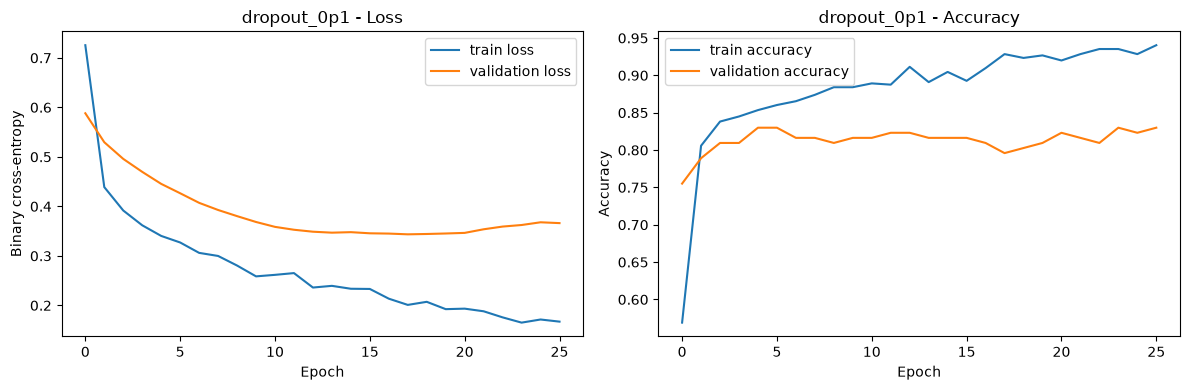

In [12]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="train loss")
    axes[0].plot(history.history["val_loss"], label="validation loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="train accuracy")
    axes[1].plot(history.history["val_accuracy"], label="validation accuracy")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.tight_layout()
    plt.show()


plot_history(best_history, best_experiment)


### 13.1 Callback Verification

The selected run was `dropout_0p1`.

| Check | Current run |
|---|---:|
| Best validation-loss epoch | 18 |
| Training stopped after epoch | 26 |
| Epochs allowed after the best point | 8 |
| `patience` | 8 |
| Best weights restored | yes |
| Best checkpoint saved | yes |

This is the expected EarlyStopping behavior: validation loss reached its best value at epoch 18, then training continued for the patience window and stopped at epoch 26. `restore_best_weights=True` returned the in-memory model to the best validation-loss weights, while `ModelCheckpoint` persisted the best state to disk.

This directly verifies that the callbacks are doing more than just appearing in the code.


## 14. Final Day 5 Test Evaluation

The Day 5 configuration is now locked from validation results, so I evaluate it on the same Day 1 held-out test split for the final Sprint 1 comparison.

This is **not** a tuning step. The threshold remains `0.5`, and I do not change architecture, learning rate, dropout, batch size, or threshold after seeing these test results.


In [13]:
test_score = best_model.predict(X_test_nn, verbose=0).ravel()
test_pred = (test_score >= 0.5).astype(int)

day5_test_metrics = classification_metrics(y_test_nn, test_score)
day5_test_table = pd.DataFrame([{
    "model": "Day 5 tuned neural network",
    **day5_test_metrics,
    "threshold": 0.5,
    "params": int(best_row["params"]),
    "selected_experiment": best_experiment,
}])

display(day5_test_table.round(4))
day5_test_table.to_csv(OUTPUT_DIR / "day5_test_metrics.csv", index=False)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold,params,selected_experiment
0,Day 5 tuned neural network,0.8641,0.8812,0.8725,0.8768,0.9304,0.9328,0.5,4161,dropout_0p1


## 15. Confusion Matrix, ROC Curve, and PR Curve

Because this is a binary medical classification dataset, I look beyond accuracy. Recall, ROC-AUC, PR-AUC, and the confusion matrix give a clearer view of what the model is doing.


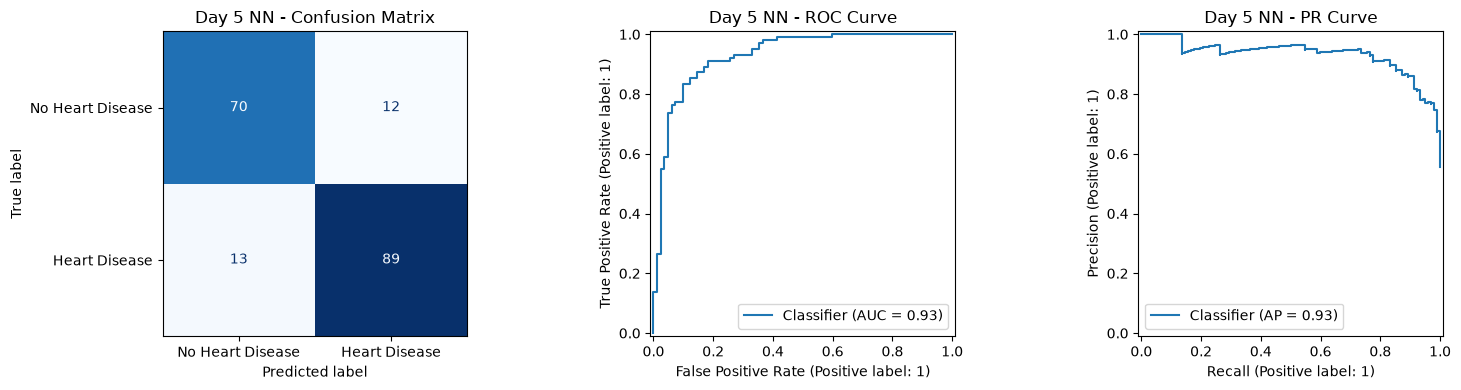

,true_negative,false_positive,false_negative,true_positive
0,70,12,13,89


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test_nn,
    test_pred,
    display_labels=["No Heart Disease", "Heart Disease"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Day 5 NN - Confusion Matrix")

RocCurveDisplay.from_predictions(y_test_nn, test_score, ax=axes[1])
axes[1].set_title("Day 5 NN - ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test_nn, test_score, ax=axes[2])
axes[2].set_title("Day 5 NN - PR Curve")

fig.tight_layout()
plt.show()

cm = confusion_matrix(y_test_nn, test_pred)
tn, fp, fn, tp = cm.ravel()
error_summary = pd.DataFrame([{
    "true_negative": tn,
    "false_positive": fp,
    "false_negative": fn,
    "true_positive": tp,
}])
display(error_summary)


## 16. Baseline vs Day 4 NN vs Day 5 Tuned NN

The table below uses the same Day 1 test split for all three reported models.

The comparison is interpreted in two ways:

- **threshold-dependent metrics** such as precision, recall, and F1 at threshold `0.5`;
- **ranking metrics** such as ROC-AUC, which do not depend on choosing one classification threshold.


In [15]:
comparison = pd.DataFrame([
    {
        "model": "Day 1 tuned Random Forest",
        "accuracy": 0.8696,
        "precision": 0.8679,
        "recall": 0.9020,
        "f1": 0.8846,
        "roc_auc": 0.9173,
        "params": np.nan,
        "notes": "classical baseline from Day 1/final project",
    },
    {
        "model": "Day 4 NN",
        "accuracy": 0.8587,
        "precision": 0.8585,
        "recall": 0.8922,
        "f1": 0.8750,
        "roc_auc": 0.9014,
        "params": 4161,
        "notes": "BatchNorm + Dropout, last Day 4 selected model",
    },
    {
        "model": "Day 5 tuned NN",
        "accuracy": day5_test_metrics["accuracy"],
        "precision": day5_test_metrics["precision"],
        "recall": day5_test_metrics["recall"],
        "f1": day5_test_metrics["f1"],
        "roc_auc": day5_test_metrics["roc_auc"],
        "params": int(best_row["params"]),
        "notes": "selected by validation loss, evaluated once on test",
    },
])

comparison["f1_delta_vs_rf"] = comparison["f1"] - 0.8846
comparison["roc_auc_delta_vs_rf"] = comparison["roc_auc"] - 0.9173

display(comparison.round(4))
comparison.to_csv(OUTPUT_DIR / "day5_model_comparison.csv", index=False)


,model,accuracy,precision,recall,f1,roc_auc,params,notes,f1_delta_vs_rf,roc_auc_delta_vs_rf
0,Day 1 tuned Random Forest,0.8696,0.8679,0.9020,0.8846,0.9173,NaN,classical baseline from Day 1/final project,0.0000,0.0000
1,Day 4 NN,0.8587,0.8585,0.8922,0.8750,0.9014,4161.0,"BatchNorm + Dropout, last Day 4 selected model",-0.0096,-0.0159
2,Day 5 tuned NN,0.8641,0.8812,0.8725,0.8768,0.9304,4161.0,"selected by validation loss, evaluated once on...",-0.0078,0.0131


## 17. Complexity and Inference Notes

This is a small structured/tabular dataset, so a larger neural network is not automatically better.

I report parameter count and checkpoint size because model quality is not only about predictive metrics. For a future deployment, the **preprocessing logic and trained model must be versioned together**; the neural-network file alone is not enough to reproduce inference from raw patient rows.


In [16]:
best_checkpoint_path = Path(best_row["checkpoint_path"])
checkpoint_size_kb = best_checkpoint_path.stat().st_size / 1024 if best_checkpoint_path.exists() else np.nan

complexity_table = pd.DataFrame([
    {
        "model": "Day 4 NN architecture",
        "hidden_units": "(64, 32)",
        "params": 4161,
        "checkpoint_size_kb": np.nan,
        "comment": "small enough for instant CPU inference",
    },
    {
        "model": "Day 5 selected NN",
        "hidden_units": best_row["hidden_units"],
        "params": int(best_row["params"]),
        "checkpoint_size_kb": checkpoint_size_kb,
        "comment": "model size is tiny; preprocessing will dominate deployment complexity",
    },
])

display(complexity_table.round(2))
complexity_table.to_csv(OUTPUT_DIR / "day5_complexity_notes.csv", index=False)


,model,hidden_units,params,checkpoint_size_kb,comment
0,Day 4 NN architecture,"(64, 32)",4161,NaN,small enough for instant CPU inference
1,Day 5 selected NN,"(64, 32)",4161,82.75,model size is tiny; preprocessing will dominat...


## 18. Selection Rationale and Result Interpretation

I selected the Day 5 model with the **lowest validation loss**, not the highest test score. This keeps model selection tied to validation evidence and to the same objective monitored by `EarlyStopping` and `ModelCheckpoint`.

The selected configuration was:

- hidden units: `(64, 32)`
- learning rate: `0.001`
- dropout: `0.1`
- batch size: `32`

The final Day 5 test result was:

- Accuracy: **0.8641**
- Precision: **0.8812**
- Recall: **0.8725**
- F1: **0.8768**
- ROC-AUC: **0.9304**
- PR-AUC: **0.9328**

Compared with the Day 4 NN, Day 5 improved F1 slightly (`+0.0018`) and improved ROC-AUC substantially (`+0.0290`).

Compared with the tuned Random Forest baseline:

- F1 is still lower by about **0.0078**;
- ROC-AUC is higher by about **0.0131**.

So the result is not simply "the NN won" or "the NN lost." At threshold `0.5`, the Random Forest still has the stronger F1/recall trade-off. However, the tuned NN ranks positive vs negative cases better according to ROC-AUC.

### Metric-alignment note

There is also an important modeling lesson here: the configuration with the lowest validation loss is not necessarily the configuration with the highest validation F1. For this sprint I keep validation loss as the selection rule because it is the optimized training objective and the callback monitor. In a real medical deployment, model selection and threshold tuning should be aligned explicitly with the clinical/business objective, such as recall, F1, or the cost of false negatives, using validation data only.


## 19. Day 5 Requirement Check

| Requirement | Evidence |
|---|---|
| Tune one variable at a time | Stages 1-4 |
| Tune learning rate | Stage 1 |
| Tune width/depth | Stage 2 |
| Tune dropout | Stage 3 |
| Tune batch size | Stage 4 |
| Use EarlyStopping | `run_experiment()` + Callback Verification |
| Verify EarlyStopping behavior | Best epoch 18, stopped at epoch 26 |
| Use ModelCheckpoint | `run_experiment()` callbacks |
| Persist best checkpoint | Checkpoint path + saved model size |
| Record validation score for each run | Experiment tracking table |
| Select best config using validation only | Best Configuration section |
| Avoid Day 5 test-driven tuning | Split notes + selection rule |
| Final test evaluation | Final Day 5 Test Evaluation |
| Compare baseline vs NN | Comparison table |
| Include diagnostic evidence | Loss/accuracy curves, confusion matrix, ROC, PR |
| Consider complexity | Parameter count + checkpoint size |
| Interpret actual outcome | Selection Rationale and Result Interpretation |
| Sprint Review and Retrospective | Sections below |


## 20. Sprint Review

**Sprint goal:** Use the existing Heart Disease project to establish a classical baseline, understand neural-network training, build a first Keras model, then tune and evaluate it properly.

**Completed**

- Day 1 established the tuned Random Forest baseline and fixed the comparison split.
- Day 2 connected activations, sigmoid output, and binary cross-entropy to this project.
- Day 3 explained the training loop, backpropagation, optimizers, batches/epochs, and learning-rate behavior.
- Day 4 trained the first Keras network and diagnosed late-epoch overfitting.
- Day 5 added `EarlyStopping`, `ModelCheckpoint`, systematic one-variable-at-a-time tuning, experiment tracking, and the final comparison.

**Day 5 evidence**

- 13 recorded tuning runs across learning rate, architecture, dropout, and batch size;
- validation-only model selection;
- EarlyStopping verification: best epoch 18, stopped at epoch 26;
- saved best checkpoint;
- selected-model training curves;
- final Day 5 test metrics;
- confusion matrix, ROC curve, and PR curve;
- Day 1 Random Forest vs Day 4 NN vs Day 5 tuned NN comparison;
- parameter-count and checkpoint-size check.

**Main result**

The tuned NN reached **F1 = 0.8768** and **ROC-AUC = 0.9304**. The Random Forest still leads on F1 (`0.8846`), while the tuned NN leads on ROC-AUC (`0.9304` vs `0.9173`). This makes the final conclusion metric-dependent rather than forcing one model to be declared universally better.

**Moved to Sprint 2**

- Classification-threshold tuning is deferred so it can be optimized on validation data with an explicitly chosen objective.
- MLflow is deferred because the CSV experiment log is sufficient for Sprint 1; it becomes useful once the experiment volume grows.
- Deployment packaging should version the preprocessing pipeline and trained model together.


## 21. Retrospective

**What went well**

- The project stayed consistent from Day 1 to Day 5 instead of changing datasets or evaluation splits.
- Day 5 tuning decisions used validation data only; Day 5 did not use test metrics to choose hyperparameters.
- EarlyStopping prevented unnecessary late-epoch training and restored the best validation-loss state.
- ModelCheckpoint preserved the best state independently of the in-memory model.
- The experiment table made every tuning decision traceable.
- The final interpretation compares both threshold-dependent metrics and ROC-AUC instead of relying on accuracy alone.

**What I would improve**

- I would create the reusable experiment runner earlier in the sprint so every NN run is logged in the same format from Day 4 onward.
- I would define the primary model-selection metric before tuning. Validation loss is a clean training objective, but for a medical classifier the eventual deployment objective may prioritize recall or another cost-sensitive metric.
- I would package preprocessing and the trained model together before deployment so raw-data inference is reproducible.

**Concrete action for Sprint 2**

Start Sprint 2 with one lightweight experiment log and one explicit evaluation contract: primary validation metric, secondary metrics, threshold-selection rule, configuration, artifact path, and a final test metric only after selection is complete.


## 22. Final Summary

Day 5 completed the Sprint 1 close-out with systematic tuning, callback-based training control, experiment tracking, final evaluation, and baseline comparison.

The selected neural network achieved **F1 = 0.8768** and **ROC-AUC = 0.9304** on the common test split. It did not beat the tuned Random Forest on F1, but it did exceed it on ROC-AUC. That is a more useful conclusion than forcing a single "winner": the Random Forest currently gives the stronger threshold-0.5 classification trade-off, while the tuned NN shows stronger ranking ability.

The main engineering outcome of the sprint is therefore not only a model score. It is a reproducible path from baseline -> first NN -> diagnosed overfitting -> callbacks -> controlled tuning -> validation-based selection -> final comparison, with enough evidence to explain why the final result looks the way it does.
